# Detecció d'opinions (pràctica 2.a)
### Recursos

- Movie Reviews Corpus

### Enunciat

- Implementeu un detector d'opinions positives o negatives amb alguns algoritmes d'aprenentatge supervisat de l'sklearn # perceptro, svm i arbres (3 models diferents)

- Utilitzeu com a dades el Movie Reviews Corpus de l'NLTK

- Dissenyeu i apliqueu un protocol de validació

- Utilitzeu el preprocés que cregueu més convenient: eliminació d'stop words, signes de puntuació... (reduir la dimensionalitat del vocabulari (amb lemes de diccionary o symsets))

- Utilitzeu el CountVectorizer per representar la informació

- Doneu la precisió (accuracy) i les matrius de confusió

- Analitzeu els resultats (Analitzar les frases que fallen)

num_features = 5000 <-- fixar mida de diccionari

## NLTK’s Movie Reviews Corpus

### Polarity corpus:

- 1000 exemples positius i 1000 negatius

### Requeriments:

In [28]:
import re
import nltk
from nltk.corpus import movie_reviews
from nltk.corpus import sentiwordnet as swn
from nltk.wsd import lesk
from nltk.tokenize import word_tokenize
from textserver import TextServer
from nltk.corpus import wordnet as wn
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('sentiwordnet')

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\david\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!

In [32]:
documents = [(movie_reviews.raw(fileid), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]
X = [doc[0] for doc in documents]
y = [doc[1] for doc in documents]

def preprocessing(X):
    for i in range(len(X)):
        cleaned_text = re.sub(r'\d+', '', X[i])  # Eliminar els números
        cleaned_text = re.sub(r'_+', '', cleaned_text)  # Eliminar els _
        cleaned_text = re.sub(r',+', '', cleaned_text)  # Eliminar els ,
        cleaned_text = cleaned_text.replace('.', '')  # Eliminar els .
        cleaned_text = re.sub(r'[ \t]+', ' ', cleaned_text) # Canviar (1 o més)espais i tabulacions per 1 espai
        X[i] = cleaned_text

# Dividir en entrenament i test (80% entrenament, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_pp = X_train.copy()
preprocessing(X_train_pp)
X_test_pp = X_test.copy()
preprocessing(X_test_pp)

SVM Performance:
              precision    recall  f1-score   support

         neg       0.77      0.79      0.78       199
         pos       0.79      0.77      0.78       201

    accuracy                           0.78       400
   macro avg       0.78      0.78      0.78       400
weighted avg       0.78      0.78      0.78       400



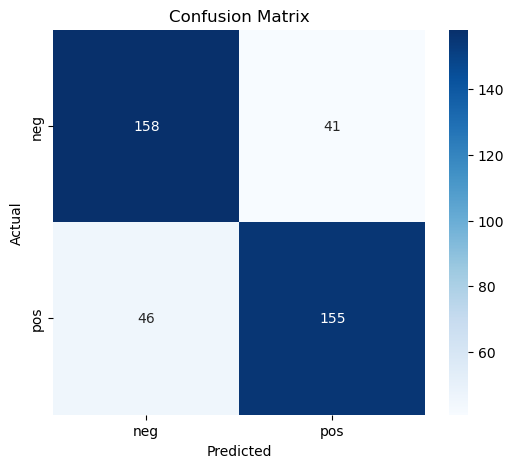

In [33]:
vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X_train_features = vectorizer.fit_transform(X_train_pp)

svm = SVC(kernel='linear')
svm.fit(X_train_features, y_train)

X_test_features = vectorizer.transform(X_test_pp)
y_pred = svm.predict(X_test_features)

accuracy_svm = accuracy_score(y_test, y_pred)

print("SVM Performance:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

SVM Performance:
              precision    recall  f1-score   support

         neg       0.84      0.82      0.83       199
         pos       0.83      0.85      0.84       201

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



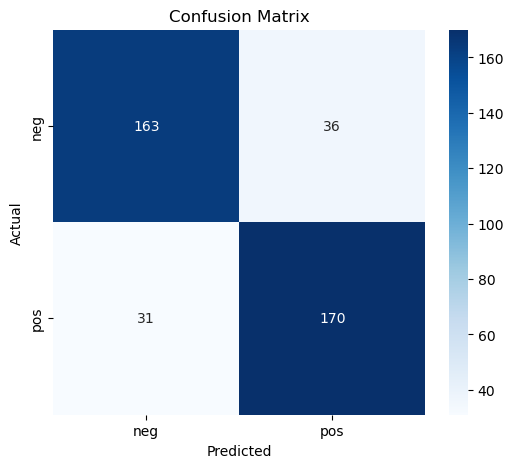

,params,rank_test_score,mean_test_score,std_test_score
model,,,,
"(1, 2)_10_rbf","{'countvectorizer__ngram_range': (1, 2), 'svc_...",1,0.810625,0.022587
"(1, 1)_10_rbf","{'countvectorizer__ngram_range': (1, 1), 'svc_...",1,0.810625,0.019823
"(1, 3)_10_rbf","{'countvectorizer__ngram_range': (1, 3), 'svc_...",3,0.810625,0.022930
"(1, 3)_1_rbf","{'countvectorizer__ngram_range': (1, 3), 'svc_...",4,0.805000,0.019223
"(1, 1)_1_rbf","{'countvectorizer__ngram_range': (1, 1), 'svc_...",5,0.804375,0.019223
"(1, 2)_1_rbf","{'countvectorizer__ngram_range': (1, 2), 'svc_...",5,0.804375,0.020406
"(1, 1)_0.1_linear","{'countvectorizer__ngram_range': (1, 1), 'svc_...",7,0.800000,0.016887
"(1, 1)_10_linear","{'countvectorizer__ngram_range': (1, 1), 'svc_...",8,0.799375,0.014711
"(1, 1)_1_linear","{'countvectorizer__ngram_range': (1, 1), 'svc_...",8,0.799375,0.014711


In [34]:
pipeline = make_pipeline(CountVectorizer(stop_words='english', max_features=5000), SVC())

param_grid = {
    'countvectorizer__ngram_range': [(1,1), (1,2), (1,3)],
    'svc__kernel': ['linear', 'rbf'],
    'svc__C': [0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_svm = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

gs_svm.fit(X_train_pp, y_train)

y_pred = gs_svm.predict(X_test_pp)

print("SVM Performance:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=gs_svm.classes_, yticklabels=gs_svm.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

results_df = pd.DataFrame(gs_svm.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("model")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

Perceptron Performance:
              precision    recall  f1-score   support

         neg       0.80      0.80      0.80       199
         pos       0.81      0.80      0.80       201

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



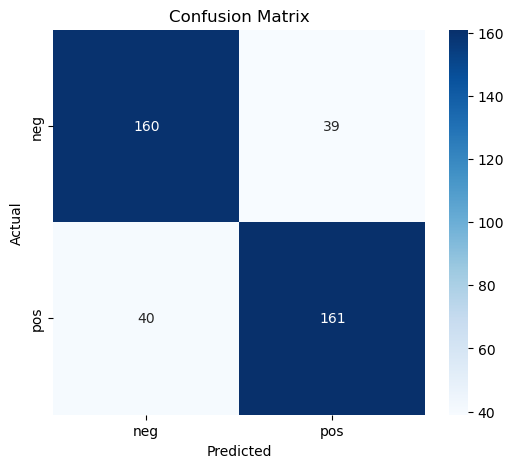

,params,rank_test_score,mean_test_score,std_test_score
model,,,,
"(1, 2)_0.0001_None","{'countvectorizer__ngram_range': (1, 2), 'perc...",1,0.808125,0.018392
"(1, 2)_0.01_None","{'countvectorizer__ngram_range': (1, 2), 'perc...",1,0.808125,0.018392
"(1, 2)_0.001_None","{'countvectorizer__ngram_range': (1, 2), 'perc...",1,0.808125,0.018392
"(1, 3)_0.0001_l1","{'countvectorizer__ngram_range': (1, 3), 'perc...",4,0.803750,0.020000
"(1, 2)_0.0001_l1","{'countvectorizer__ngram_range': (1, 2), 'perc...",5,0.800625,0.018049
"(1, 1)_0.01_None","{'countvectorizer__ngram_range': (1, 1), 'perc...",6,0.800625,0.026175
"(1, 1)_0.0001_None","{'countvectorizer__ngram_range': (1, 1), 'perc...",6,0.800625,0.026175
"(1, 1)_0.001_None","{'countvectorizer__ngram_range': (1, 1), 'perc...",6,0.800625,0.026175
"(1, 1)_0.0001_l2","{'countvectorizer__ngram_range': (1, 1), 'perc...",9,0.797500,0.015737


In [35]:
pipeline = make_pipeline(CountVectorizer(stop_words='english', max_features=5000), Perceptron())

param_grid = {
    'countvectorizer__ngram_range': [(1,1), (1,2), (1,3)],
    'perceptron__penalty': [None, 'l2', 'l1'],
    'perceptron__alpha': [0.0001, 0.001, 0.01],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_per = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

gs_per.fit(X_train_pp, y_train)

y_pred = gs_per.predict(X_test_pp)

print("Perceptron Performance:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=gs_per.classes_, yticklabels=gs_per.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

results_df = pd.DataFrame(gs_per.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("model")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

XGBoost Performance:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       199
           1       0.86      0.83      0.85       201

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



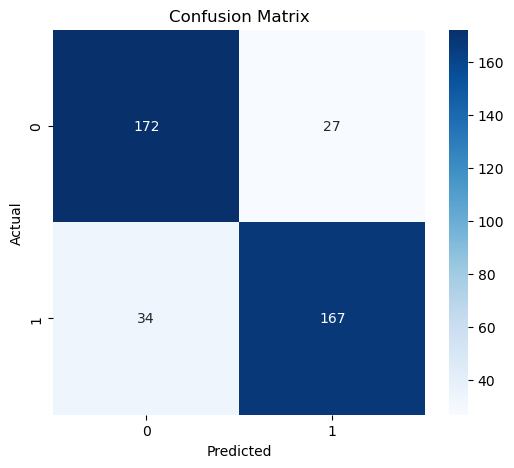

,params,rank_test_score,mean_test_score,std_test_score
model,,,,
"(1, 1)_0.1_3_200_0.8","{'countvectorizer__ngram_range': (1, 1), 'xgbc...",1,0.815625,0.018854
"(1, 1)_0.3_3_100_0.8","{'countvectorizer__ngram_range': (1, 1), 'xgbc...",2,0.808125,0.025202
"(1, 1)_0.3_3_200_0.8","{'countvectorizer__ngram_range': (1, 1), 'xgbc...",2,0.808125,0.026265
"(1, 3)_0.1_3_200_0.8","{'countvectorizer__ngram_range': (1, 3), 'xgbc...",4,0.806875,0.017162
"(1, 2)_0.1_3_200_0.8","{'countvectorizer__ngram_range': (1, 2), 'xgbc...",4,0.806875,0.017162
"(1, 2)_0.1_6_200_1.0","{'countvectorizer__ngram_range': (1, 2), 'xgbc...",6,0.805625,0.024479
"(1, 3)_0.1_6_200_1.0","{'countvectorizer__ngram_range': (1, 3), 'xgbc...",6,0.805625,0.024479
"(1, 1)_0.3_3_200_1.0","{'countvectorizer__ngram_range': (1, 1), 'xgbc...",6,0.805625,0.015233
"(1, 3)_0.1_6_200_0.8","{'countvectorizer__ngram_range': (1, 3), 'xgbc...",9,0.803750,0.021232


In [36]:
pipeline = make_pipeline(CountVectorizer(stop_words='english', max_features=5000), XGBClassifier(eval_metric='logloss'))

param_grid = {
    'countvectorizer__ngram_range': [(1,1), (1,2), (1,3)],
    'xgbclassifier__n_estimators': [100, 200],
    'xgbclassifier__max_depth': [3, 6],
    'xgbclassifier__learning_rate': [0.1, 0.3],
    'xgbclassifier__subsample': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_xgb = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
gs_xgb.fit(X_train_pp, y_train_encoded)

y_test_encoded = le.fit_transform(y_test)
y_pred = gs_xgb.predict(X_test_pp)

print("XGBoost Performance:")
print(classification_report(y_test_encoded, y_pred))

cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=gs_xgb.classes_, yticklabels=gs_xgb.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

results_df = pd.DataFrame(gs_xgb.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("model")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

# Detecció d'opinions (pràctica 2.b)

### Enunciat

- Implementeu un detector d'opinions positives o negatives no supervisat

    1. Apliqueu l'UKB per obtenir els synsets de les paraules (nltk lesk)
    2. Obtingueu els valors SentiWordnet de cada synset

- Utilitzeu com a dades el/els conjunts de test que hagueu utilitzat a la pràctica 2.a

- Penseu en com podeu combinar aquests valors per obtenir un resultat

- Penseu que fareu si el synset no hi és a SentiWordnet

- Penseu quines categories utilitzareu:

    - només adjectius
    - noms, adjectius i adverbis
    - noms, adjectius, verbs i adverbis (com a minim fer aquestes combinacions)

- Analitzeu els resultats i compareu-los amb els de la part supervisada

    - Desambiguació de 10 frases amb lesk and UKB i comparar la desambiguació que han fet -----> (Com que la diferencia no es tan gran farem servir lesk)

In [38]:
wnl = nltk.stem.WordNetLemmatizer()
d = {'NN': 'n', 'NNS': 'n', 
       'JJ': 'a', 'JJR': 'a', 'JJS': 'a', 
       'VB': 'v', 'VBD': 'v', 'VBG': 'v', 'VBN': 'v', 'VBP': 'v', 'VBZ': 'v', 
       'RB': 'r', 'RBR': 'r', 'RBS': 'r'}

def lemmatize(p):
  if p[1] in d:
    return wnl.lemmatize(p[0], pos=d[p[1]]), d[p[1]]
  return p[0], None

def search_equal(res_search, search_term, i):
    while i < len(res_search):
        if search_term == res_search[i][0]:
            return True
        i += 1
    return False

def print_synsets_side_by_side(frase, resultat_lesk, resultat_ukb):
  print(frase)
  i = 0
  j = 0
  while i < len(resultat_lesk):
      k = j
      print(f"lesk: {resultat_lesk[i][0]} {resultat_lesk[i][1]} {resultat_lesk[i][2]}", end=" " if k < len(resultat_ukb) else "\n")
      printed = False
      while k < len(resultat_ukb):
          if resultat_lesk[i][0] == resultat_ukb[k][0]:
              printed = True
              print(f"{' ' * (150 - len(resultat_lesk[i][0]) - len(resultat_lesk[i][1]) - len(resultat_lesk[i][2]))} ukb: {resultat_ukb[k][0]} {resultat_ukb[k][1]} {resultat_ukb[k][2]}")
              k += 1
              break
          else:
              if search_equal(resultat_lesk, resultat_ukb[k][0], i):
                  if not printed:
                      print()
                  break
              printed = True
              print(f"\n{' '*159} ukb: {resultat_ukb[k][0]} {resultat_ukb[k][1]} {resultat_ukb[k][2]}")
              k += 1
      
      j = k
      i += 1

  while j < len(resultat_ukb):
      print(f"{' ' * 150} ukb: {resultat_ukb[j][0]} {resultat_ukb[j][1]} {resultat_ukb[j][2]}")
      j += 1

In [54]:
ts = TextServer('davidvazquez', 'c4tSX16B!', 'senses') # UKB
synset_table = ts.senses(frase)
resultat_ukb = []
for frase_synset in synset_table:
    for synset in frase_synset:
        if synset[4] != 'N/A':
            syn = wn.synset_from_pos_and_offset(synset[4][-1], int(synset[4][:-2]))
            resultat_ukb.append((synset[0],syn.name(), syn.definition()))
        else:
            resultat_lesk.append((synset[0],"", ""))

In [55]:
frase = movie_reviews.raw(movie_reviews.fileids('pos')[:2][0]).split("\n")[0] # Lesk
words = nltk.word_tokenize(frase, language='english')
tags = nltk.pos_tag(words)
resultat_lesk = []
for pair in tags:
    lem = lemmatize(pair)
    if lem[1] != None:
        synset = nltk.wsd.lesk(frase, *lem)
        if synset:
            resultat_lesk.append((pair[0],synset.name(), synset.definition()))
        else:
            resultat_lesk.append((pair[0],"", ""))

In [56]:
print_synsets_side_by_side(frase, resultat_lesk=resultat_lesk, resultat_ukb=resultat_ukb)

films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . 
lesk: films movie.n.01 a form of entertainment that enacts a story by sound and a sequence of images giving the illusion of continuous movement                 ukb: films movie.n.01 a form of entertainment that enacts a story by sound and a sequence of images giving the illusion of continuous movement
lesk: adapted adapt.v.01 make fit for, or change to suit a new purpose                                                                                          ukb: adapted adapt.v.01 make fit for, or change to suit a new purpose
lesk: comic comic.a.02 of or relating to or characteristic of comedy                                                                                            ukb: comic amusing.s.02 arousing or prov

lesk=ukb -> success, spawn, world, never, hell
lesk -> comic, plenty(f), superman, comic
ukb -> books, kids, ghost(f), is(f), been, book
lesk>ukb -> have, had
ukb>lesk ->
casper -> mal(lesk)
there -> mal(ukb)

In [75]:
def opinio_diferencia(synset):
    if synset:
        senti_synset = swn.senti_synset(synset.name())
        return senti_synset.pos_score() - senti_synset.neg_score()
    return 0.0  # Si no trobem cap synset, retornem un sentiment neutral

def opinio_diferencia_cuadrada(synset):
    if synset:
        senti_synset = swn.senti_synset(synset.name())
        return senti_synset.pos_score()**2 - senti_synset.neg_score()**2
    return 0.0  # Si no trobem cap synset, retornem un sentiment neutral

def calcular_opinio_text(text, accepted = ["n", "v", "r", "a"], calc_opinio = opinio_diferencia, filtre = 0):
    sentiment_score = 0.0
    
    words = nltk.word_tokenize(text, language='english')
    tags = nltk.pos_tag(words)

    if filtre > 0:
        for pair in tags:
            lem = lemmatize(pair)
            if lem[1] != None and lem[1] in accepted:
                synset = nltk.wsd.lesk(text, *lem)
                c = calc_opinio(synset)
                sentiment_score += c if abs(c) >= filtre else 0
    else:
        for pair in tags:
            lem = lemmatize(pair)
            if lem[1] != None and lem[1] in accepted:
                synset = nltk.wsd.lesk(text, *lem)
                sentiment_score += calc_opinio(synset)

    return "pos" if sentiment_score >= 0 else "neg"


In [81]:
print("Adjectius:")

y_pred = [calcular_opinio_text(text, ["a"], calc_opinio = opinio_diferencia) for text in X_train]
print("Opinio diferencia:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["a"], calc_opinio = opinio_diferencia_cuadrada) for text in X_train]
print("Opinio diferencia cuadrada:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["a"], calc_opinio = opinio_diferencia, filtre = 0.25) for text in X_train]
print("Opinio diferencia amb filtre de 0.25:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["a"], calc_opinio = opinio_diferencia_cuadrada, filtre = 0.1) for text in X_train]
print("Opinio diferencia cuadrada amb filtre de 0.1:")
print(classification_report(y_train, y_pred))

Adjectius:
Opinio diferencia:
              precision    recall  f1-score   support

         neg       0.63      0.53      0.58       801
         pos       0.59      0.69      0.64       799

    accuracy                           0.61      1600
   macro avg       0.61      0.61      0.61      1600
weighted avg       0.61      0.61      0.61      1600

Opinio diferencia cuadrada:
              precision    recall  f1-score   support

         neg       0.62      0.56      0.59       801
         pos       0.60      0.65      0.62       799

    accuracy                           0.61      1600
   macro avg       0.61      0.61      0.61      1600
weighted avg       0.61      0.61      0.61      1600

Opinio diferencia amb filtre de 0.25:
              precision    recall  f1-score   support

         neg       0.63      0.56      0.59       801
         pos       0.60      0.66      0.63       799

    accuracy                           0.61      1600
   macro avg       0.61      0.6

In [82]:
print("Noms i adjectius:")

y_pred = [calcular_opinio_text(text, ["n", "a"], calc_opinio = opinio_diferencia) for text in X_train]
print("Opinio diferencia:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a"], calc_opinio = opinio_diferencia_cuadrada) for text in X_train]
print("Opinio diferencia cuadrada:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a"], calc_opinio = opinio_diferencia, filtre = 0.25) for text in X_train]
print("Opinio diferencia amb filtre de 0.25:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a"], calc_opinio = opinio_diferencia_cuadrada, filtre = 0.1) for text in X_train]
print("Opinio diferencia cuadrada amb filtre de 0.1:")
print(classification_report(y_train, y_pred))

Noms i adjectius:
Opinio diferencia:
              precision    recall  f1-score   support

         neg       0.60      0.48      0.53       801
         pos       0.57      0.69      0.62       799

    accuracy                           0.58      1600
   macro avg       0.59      0.58      0.58      1600
weighted avg       0.59      0.58      0.58      1600

Opinio diferencia cuadrada:
              precision    recall  f1-score   support

         neg       0.60      0.51      0.55       801
         pos       0.57      0.65      0.61       799

    accuracy                           0.58      1600
   macro avg       0.58      0.58      0.58      1600
weighted avg       0.58      0.58      0.58      1600

Opinio diferencia amb filtre de 0.25:
              precision    recall  f1-score   support

         neg       0.59      0.50      0.54       801
         pos       0.56      0.66      0.61       799

    accuracy                           0.58      1600
   macro avg       0.58  

In [83]:
print("Noms, adjectius i adverbis:")

y_pred = [calcular_opinio_text(text, ["n", "a", "r"], calc_opinio = opinio_diferencia) for text in X_train]
print("Opinio diferencia:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a", "r"], calc_opinio = opinio_diferencia_cuadrada) for text in X_train]
print("Opinio diferencia cuadrada:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a", "r"], calc_opinio = opinio_diferencia, filtre = 0.25) for text in X_train]
print("Opinio diferencia amb filtre de 0.25:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a", "r"], calc_opinio = opinio_diferencia_cuadrada, filtre = 0.1) for text in X_train]
print("Opinio diferencia cuadrada amb filtre de 0.1:")
print(classification_report(y_train, y_pred))

Noms, adjectius i adverbis:
Opinio diferencia:
              precision    recall  f1-score   support

         neg       0.59      0.58      0.59       801
         pos       0.59      0.60      0.60       799

    accuracy                           0.59      1600
   macro avg       0.59      0.59      0.59      1600
weighted avg       0.59      0.59      0.59      1600

Opinio diferencia cuadrada:
              precision    recall  f1-score   support

         neg       0.58      0.68      0.63       801
         pos       0.61      0.50      0.55       799

    accuracy                           0.59      1600
   macro avg       0.60      0.59      0.59      1600
weighted avg       0.59      0.59      0.59      1600

Opinio diferencia amb filtre de 0.25:
              precision    recall  f1-score   support

         neg       0.59      0.61      0.60       801
         pos       0.60      0.57      0.58       799

    accuracy                           0.59      1600
   macro avg   

In [84]:
print("Noms, adjectius, adverbis i verbs:")

y_pred = [calcular_opinio_text(text, ["n", "a", "r", "v"], calc_opinio = opinio_diferencia) for text in X_train]
print("Opinio diferencia:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a", "r", "v"], calc_opinio = opinio_diferencia_cuadrada) for text in X_train]
print("Opinio diferencia cuadrada:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a", "r", "v"], calc_opinio = opinio_diferencia, filtre = 0.25) for text in X_train]
print("Opinio diferencia amb filtre de 0.25:")
print(classification_report(y_train, y_pred))

y_pred = [calcular_opinio_text(text, ["n", "a", "r", "v"], calc_opinio = opinio_diferencia_cuadrada, filtre = 0.1) for text in X_train]
print("Opinio diferencia cuadrada amb filtre de 0.1:")
print(classification_report(y_train, y_pred))

Noms, adjectius, adverbis i verbs:
Opinio diferencia:
              precision    recall  f1-score   support

         neg       0.62      0.52      0.57       801
         pos       0.59      0.68      0.63       799

    accuracy                           0.60      1600
   macro avg       0.60      0.60      0.60      1600
weighted avg       0.60      0.60      0.60      1600

Opinio diferencia cuadrada:
              precision    recall  f1-score   support

         neg       0.60      0.63      0.61       801
         pos       0.61      0.58      0.59       799

    accuracy                           0.60      1600
   macro avg       0.60      0.60      0.60      1600
weighted avg       0.60      0.60      0.60      1600

Opinio diferencia amb filtre de 0.25:
              precision    recall  f1-score   support

         neg       0.61      0.57      0.59       801
         pos       0.59      0.63      0.61       799

    accuracy                           0.60      1600
   macro

Adjectius:
              precision    recall  f1-score   support

         neg       0.64      0.53      0.58       199
         pos       0.60      0.71      0.65       201

    accuracy                           0.62       400
   macro avg       0.62      0.62      0.61       400
weighted avg       0.62      0.62      0.61       400



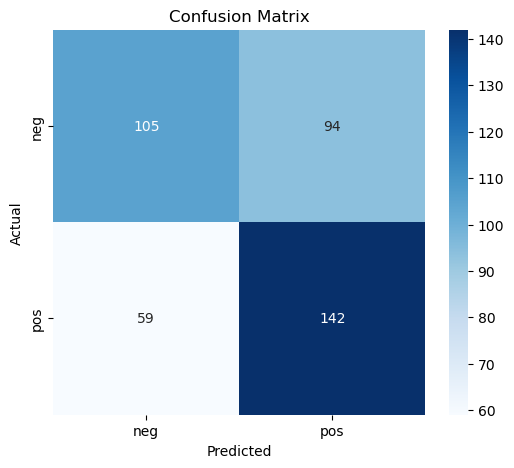

In [85]:
y_pred = [calcular_opinio_text(text, ["a"], calc_opinio = opinio_diferencia) for text in X_test]

print("Adjectius:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_pred), yticklabels=set(y_pred))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Noms, adjectius, adverbis:
              precision    recall  f1-score   support

         neg       0.59      0.46      0.52       199
         pos       0.56      0.69      0.62       201

    accuracy                           0.57       400
   macro avg       0.58      0.57      0.57       400
weighted avg       0.58      0.57      0.57       400



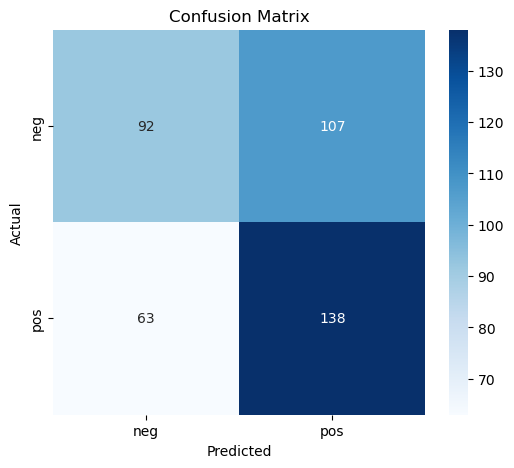

In [88]:
y_pred = [calcular_opinio_text(text, ["n", "a"], calc_opinio = opinio_diferencia) for text in X_test]

print("Noms, adjectius, adverbis:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_pred), yticklabels=set(y_pred))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Noms, adjectius, adverbis:
              precision    recall  f1-score   support

         neg       0.58      0.54      0.56       199
         pos       0.57      0.61      0.59       201

    accuracy                           0.57       400
   macro avg       0.58      0.57      0.57       400
weighted avg       0.58      0.57      0.57       400



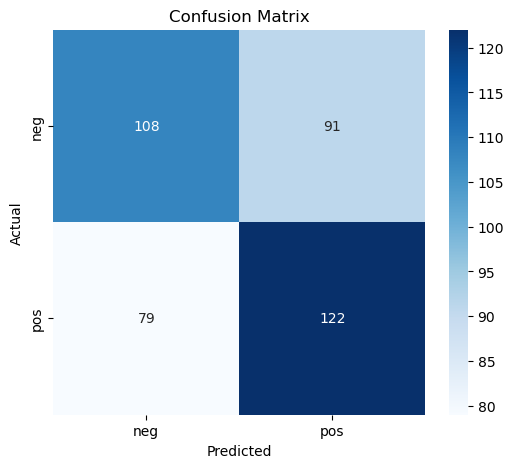

In [86]:
y_pred = [calcular_opinio_text(text, ["n", "a", "r"], calc_opinio = opinio_diferencia) for text in X_test]

print("Noms, adjectius, adverbis:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_pred), yticklabels=set(y_pred))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Noms, adjectius, adverbis i verbs:
              precision    recall  f1-score   support

         neg       0.61      0.52      0.56       199
         pos       0.58      0.67      0.62       201

    accuracy                           0.59       400
   macro avg       0.60      0.59      0.59       400
weighted avg       0.60      0.59      0.59       400



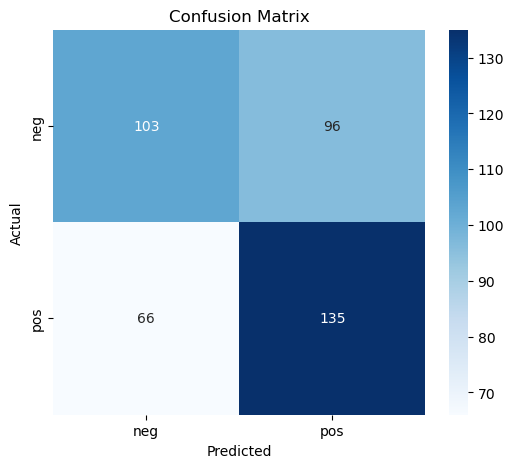

In [87]:
y_pred = [calcular_opinio_text(text, ["n", "a", "r", "v"], calc_opinio = opinio_diferencia) for text in X_test]

print("Noms, adjectius, adverbis i verbs:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_pred), yticklabels=set(y_pred))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()